In [7]:
import matplotlib.pyplot as plt
import numpy as np
from problem import get_train_data, get_test_data

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import balanced_accuracy_score
from problem import BalancedAccuracy
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
X_train, y_train = get_train_data()
X_test, y_test = get_test_data()

X_train.toarray()

array([[1., 0., 0., ..., 3., 2., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
def _preprocess_X(X_sparse):
    """CPM-like normalization + log1p, standard for scRNA-seq."""
    X = X_sparse.toarray().astype(np.float32)
    counts = X.sum(axis=1)[:, None]
    counts[counts == 0] = 1
    X = X / counts * 1e4
    return np.log1p(X)


def select_hvg(X, n_genes=2000):
    """Sélection des gènes avec la plus grande variance."""
    variances = np.var(X, axis=0)
    idx = np.argsort(variances)[-n_genes:]
    return idx

def _balance_classes(X_sparse, y):
    unique_classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    idx_balanced = []

    for cls in unique_classes:
        idx_cls = np.where(y == cls)[0]
        selected_idx = np.random.choice(idx_cls, size=min_count, replace=False)
        idx_balanced.extend(selected_idx)

    idx_balanced = np.array(sorted(idx_balanced))
    return X_sparse[idx_balanced], y[idx_balanced]

class Classifier:
    def __init__(self):
        # Pipeline principal : 3 classes (Cancer_cells, NK_cells, T_cells)
        self.pipe_main = make_pipeline(
            PCA(n_components=25),
            GradientBoostingClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                random_state=42,
            ),
        )

        # Pipeline pour affiner entre T_cells_CD4+ et T_cells_CD8+
        self.pipe_tcells = make_pipeline(
            PCA(n_components=25),
            GradientBoostingClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                random_state=42,
            ),
        )

    def fit(self, X_sparse, y):
        # Prétraitement des données
        X = _preprocess_X(X_sparse)
        self.hvg_idx_ = select_hvg(X, n_genes=2000)
        X = X[:, self.hvg_idx_]

        # Regroupement des classes pour le niveau principal
        y_main = np.array(y)  # copie
        mask_cd4 = y == "T_cells_CD4+"
        mask_cd8 = y == "T_cells_CD8+"
        y_main[mask_cd4] = "T_cells"
        y_main[mask_cd8] = "T_cells"

        mask_tcells = y_main == "T_cells"
        X_tcells = X[mask_tcells]
        y_tcells = y[mask_tcells]

        # Balance classes - main
        X_main, y_main = _balance_classes(X, y_main)

        # Entraînement du classifieur principal
        self.pipe_main.fit(X_main, y_main)

        # Entraînement du classifieur pour affiner T_cells
        self.pipe_tcells.fit(X_tcells, y_tcells)

        self.classes_main = self.pipe_main.classes_
        self.classes_tcells = self.pipe_tcells.classes_
        self.classes_ = np.array(["Cancer_cells", "NK_cells", "T_cells_CD4+", "T_cells_CD8+"])


    def predict_proba(self, X_sparse):
        X = _preprocess_X(X_sparse)
        X = X[:, self.hvg_idx_]
        n = X.shape[0]

        # Prédiction niveau principal (Cancer_cells, NK_cells, T_cells)
        p_main = self.pipe_main.predict_proba(X)
        idx_cancer = np.where(self.classes_main == "Cancer_cells")[0][0]
        idx_nk = np.where(self.classes_main == "NK_cells")[0][0]
        idx_tcells = np.where(self.classes_main == "T_cells")[0][0]

        p_cancer = p_main[:, idx_cancer]
        p_nk = p_main[:, idx_nk]
        p_tcells = p_main[:, idx_tcells]

        # Initialisation des probabilités affinées pour T_cells_CD4+ et T_cells_CD8+
        p_cd4 = np.zeros(n)
        p_cd8 = np.zeros(n)

        # Masque des cellules prédites comme T_cells
        mask_tcells = p_tcells > 0
        if np.any(mask_tcells):
            X_t = X[mask_tcells]
            p_tcells_fine = self.pipe_tcells.predict_proba(X_t)
            idx_cd4 = np.where(self.classes_tcells == "T_cells_CD4+")[0][0]
            idx_cd8 = np.where(self.classes_tcells == "T_cells_CD8+")[0][0]

            # On pondère les probabilités affinées par la probabilité d'être T_cells
            p_cd4[mask_tcells] = p_tcells[mask_tcells] * p_tcells_fine[:, idx_cd4]
            p_cd8[mask_tcells] = p_tcells[mask_tcells] * p_tcells_fine[:, idx_cd8]

        # Assemblage des probabilités finales dans l'ordre attendu
        proba = np.vstack([p_cancer, p_nk, p_cd4, p_cd8]).T
        return proba

In [63]:
clf = Classifier()
clf.fit(X_train, y_train)
# predict_proba 
y_tr_pred_proba = clf.predict_proba(X_train)
y_te_pred_proba = clf.predict_proba(X_test)

# convert to hard classification with argmax
y_tr_pred = clf.classes_[np.argmax(y_tr_pred_proba, axis=1)]
y_te_pred = clf.classes_[np.argmax(y_te_pred_proba, axis=1)]

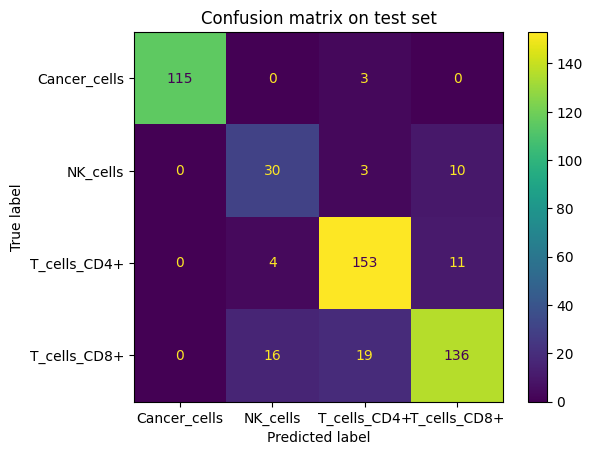

Train balanced accuracy: 0.9611267752715121
Test balanced accuracy: 0.8445716532330695


In [64]:
cm = confusion_matrix(y_test, y_te_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("Confusion matrix on test set")
plt.show()

print('Train balanced accuracy:', balanced_accuracy_score(y_train, y_tr_pred))
print('Test balanced accuracy:', balanced_accuracy_score(y_test, y_te_pred))